In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

In [6]:
# Rutas del proyecto
DATA_RAW       = Path("../data/raw/cs-training.csv")
DATA_PROCESSED = Path("../data/processed/")
FIG_DIR        = Path("../reports/figures/")

# Crear carpetas si no existen
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Estilos de gráficos
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#F8F8F8",
    "axes.grid":         True,
    "grid.color":        "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
    "figure.dpi":        120,
})

print("Rutas configuradas ✓")

Rutas configuradas ✓


In [7]:
df = pd.read_csv(DATA_RAW, index_col=0)

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas: {df.columns.tolist()}")

Dimensiones: 150,000 filas × 11 columnas

Columnas: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [8]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [9]:
print("Tipos de datos:")
print(df.dtypes)
print(f"\nValores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal nulos: {df.isnull().sum().sum():,}")

Tipos de datos:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

Valores nulos por columna:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0


In [10]:
nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje": (df.isnull().mean() * 100).round(2)
}).sort_values("porcentaje", ascending=False)

print(nulos[nulos.nulos > 0])

                    nulos  porcentaje
MonthlyIncome       29731       19.82
NumberOfDependents   3924        2.62


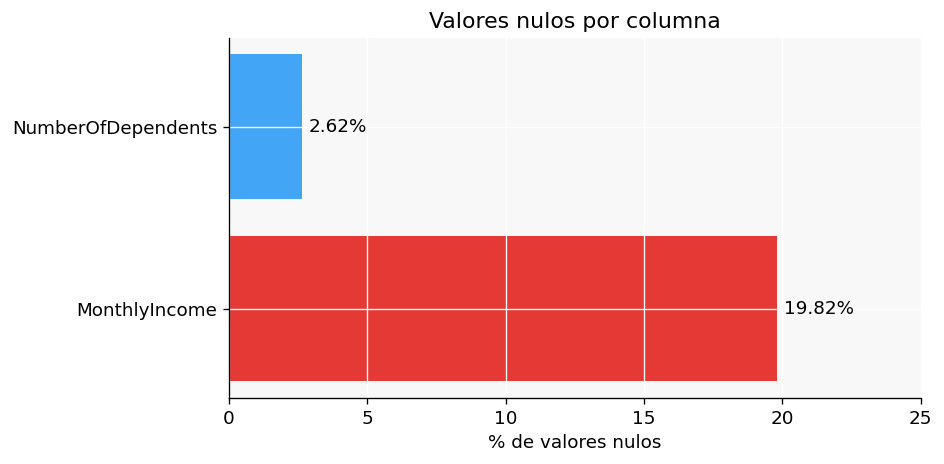

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    nulos[nulos.nulos > 0].index,
    nulos[nulos.nulos > 0]["porcentaje"],
    color=["#E53935", "#42A5F5"]
)

ax.bar_label(bars, fmt="%.2f%%", padding=4)
ax.set_xlabel("% de valores nulos")
ax.set_title("Valores nulos por columna")
ax.set_xlim(0, 25)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_nulos.png", bbox_inches="tight")
plt.show()

In [12]:
# Mediana para MonthlyIncome (robusta a outliers)
mediana_ingreso = df["MonthlyIncome"].median()
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(mediana_ingreso)

# Moda para NumberOfDependents (variable entera)
moda_dependientes = df["NumberOfDependents"].mode()[0]
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(moda_dependientes)

print(f"MonthlyIncome imputado con mediana: ${mediana_ingreso:,.0f}")
print(f"NumberOfDependents imputado con moda: {moda_dependientes:.0f}")
print(f"\nNulos restantes: {df.isnull().sum().sum()}")

MonthlyIncome imputado con mediana: $5,400
NumberOfDependents imputado con moda: 0

Nulos restantes: 0


In [13]:
df.describe().round(2)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00
mean,0.07,6.05,52.30,0.42,353.01,6418.45,8.45,0.27,1.02,0.24,0.74
std,0.25,249.76,14.77,4.19,2037.82,12890.40,5.15,4.17,1.13,4.16,1.11
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3903.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,7400.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


In [14]:
print("Clientes con edad < 18:")
print(df[df["age"] < 18]["age"].value_counts().sort_index())

print(f"\nTotal clientes con edad < 18: {(df['age'] < 18).sum()}")
print(f"Clientes con edad > 100: {(df['age'] > 100).sum()}")

Clientes con edad < 18:
age
0    1
Name: count, dtype: int64

Total clientes con edad < 18: 1
Clientes con edad > 100: 13


In [15]:
filas_antes = len(df)

df = df[(df["age"] >= 18) & (df["age"] <= 100)]

filas_despues = len(df)
print(f"Filas eliminadas: {filas_antes - filas_despues}")
print(f"Filas restantes: {filas_despues:,}")

Filas eliminadas: 14
Filas restantes: 149,986


In [16]:
# Columnas de mora que contienen códigos especiales
cols_mora = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

# Ver cuántos registros tienen estos códigos
for col in cols_mora:
    n96 = (df[col] == 96).sum()
    n98 = (df[col] == 98).sum()
    print(f"{col}: 96→{n96} registros | 98→{n98} registros")

NumberOfTime30-59DaysPastDueNotWorse: 96→5 registros | 98→264 registros
NumberOfTime60-89DaysPastDueNotWorse: 96→5 registros | 98→264 registros
NumberOfTimes90DaysLate: 96→5 registros | 98→264 registros


In [17]:
for col in cols_mora:
    df[col] = df[col].replace({96: np.nan, 98: np.nan})
    mediana_col = df[col].median()
    df[col] = df[col].fillna(mediana_col)
    print(f"{col} — mediana usada: {mediana_col}")

print(f"\nNulos restantes: {df.isnull().sum().sum()}")

NumberOfTime30-59DaysPastDueNotWorse — mediana usada: 0.0
NumberOfTime60-89DaysPastDueNotWorse — mediana usada: 0.0
NumberOfTimes90DaysLate — mediana usada: 0.0

Nulos restantes: 0


In [18]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

df.to_csv(DATA_PROCESSED / "credit_clean.csv", index=True)

print(f"Dataset limpio guardado ✓")
print(f"Dimensiones finales: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset limpio guardado ✓
Dimensiones finales: 149,986 filas × 11 columnas


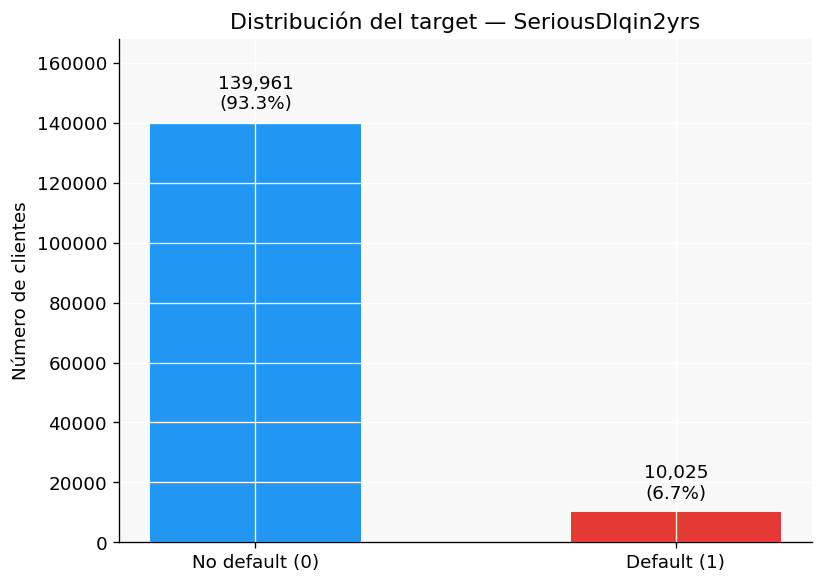

In [19]:
conteo = df["SeriousDlqin2yrs"].value_counts()
porcentaje = df["SeriousDlqin2yrs"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["No default (0)", "Default (1)"],
    conteo.values,
    color=["#2196F3", "#E53935"],
    width=0.5
)

ax.bar_label(
    bars,
    labels=[f"{v:,}\n({p:.1f}%)" for v, p in zip(conteo.values, porcentaje.values)],
    padding=6
)

ax.set_ylabel("Número de clientes")
ax.set_title("Distribución del target — SeriousDlqin2yrs")
ax.set_ylim(0, conteo.max() * 1.2)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_target_distribucion.png", bbox_inches="tight")
plt.show()

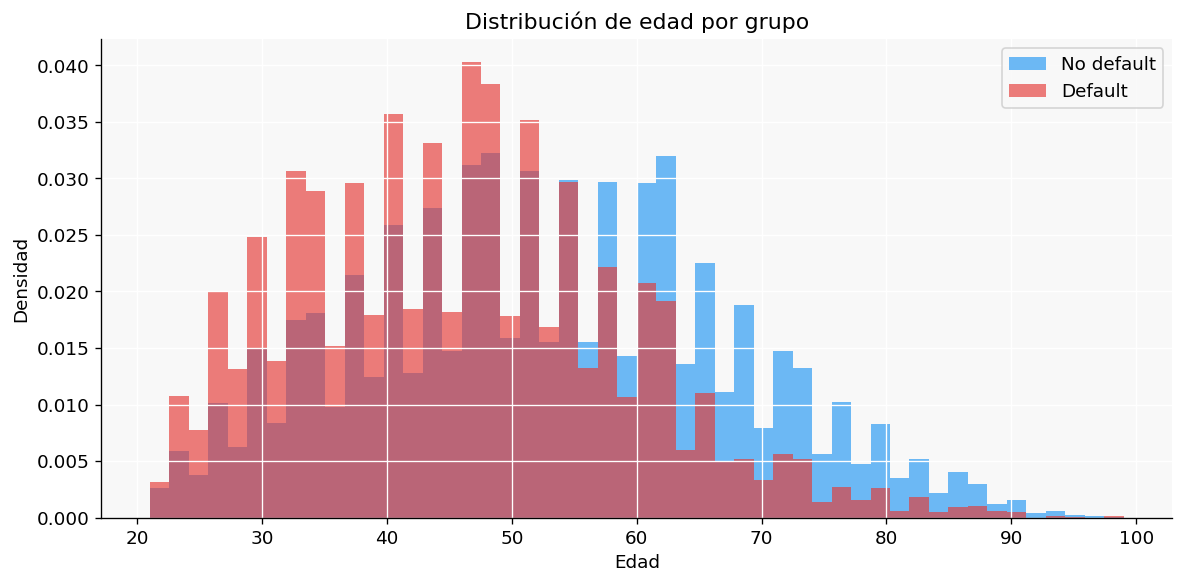

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df[df["SeriousDlqin2yrs"]==0]["age"], 
        bins=50, alpha=0.65, color="#2196F3", 
        label="No default", density=True)
ax.hist(df[df["SeriousDlqin2yrs"]==1]["age"], 
        bins=50, alpha=0.65, color="#E53935", 
        label="Default", density=True)

ax.set_xlabel("Edad")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de edad por grupo")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "03_edad_distribucion.png", bbox_inches="tight")
plt.show()

In [21]:
df["segmento_edad"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
)

edad_stats = df.groupby("segmento_edad", observed=True)["SeriousDlqin2yrs"].agg(
    total="count",
    defaults="sum"
).assign(tasa_default=lambda x: x["defaults"] / x["total"] * 100)

print(edad_stats.round(2))

               total  defaults  tasa_default
segmento_edad                               
18-25           3027       338         11.17
26-35          18458      2053         11.12
36-45          29819      2628          8.81
46-55          36690      2786          7.59
56-65          33406      1531          4.58
65+            28586       689          2.41


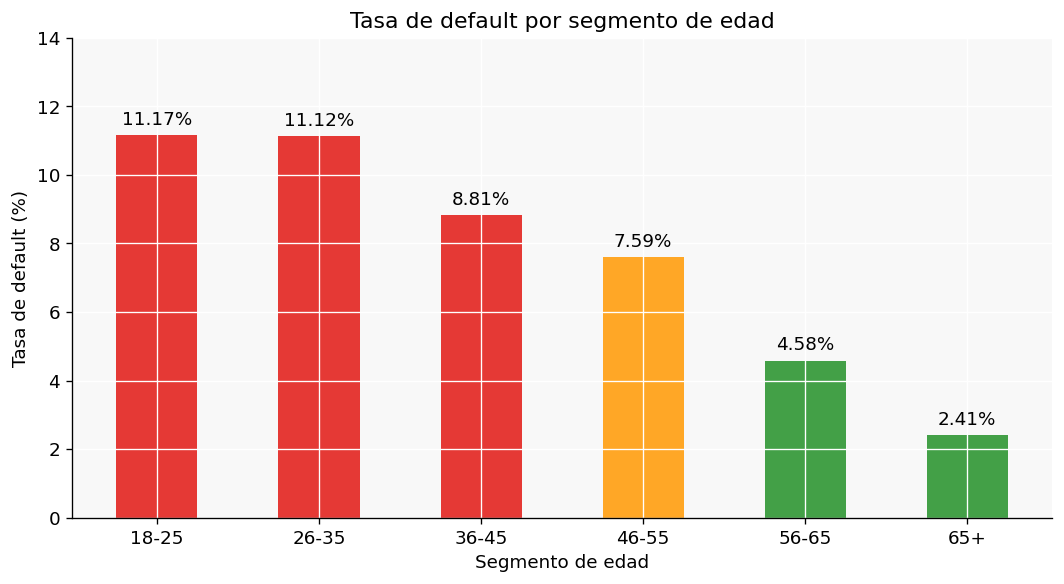

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    edad_stats.index.astype(str),
    edad_stats["tasa_default"],
    color=["#E53935" if t > 8 else "#FFA726" if t > 5 else "#43A047" 
           for t in edad_stats["tasa_default"]],
    width=0.5
)

ax.bar_label(bars, fmt="%.2f%%", padding=4)
ax.set_xlabel("Segmento de edad")
ax.set_ylabel("Tasa de default (%)")
ax.set_title("Tasa de default por segmento de edad")
ax.set_ylim(0, 14)

plt.tight_layout()
plt.savefig(FIG_DIR / "04_default_por_edad.png", bbox_inches="tight")
plt.show()

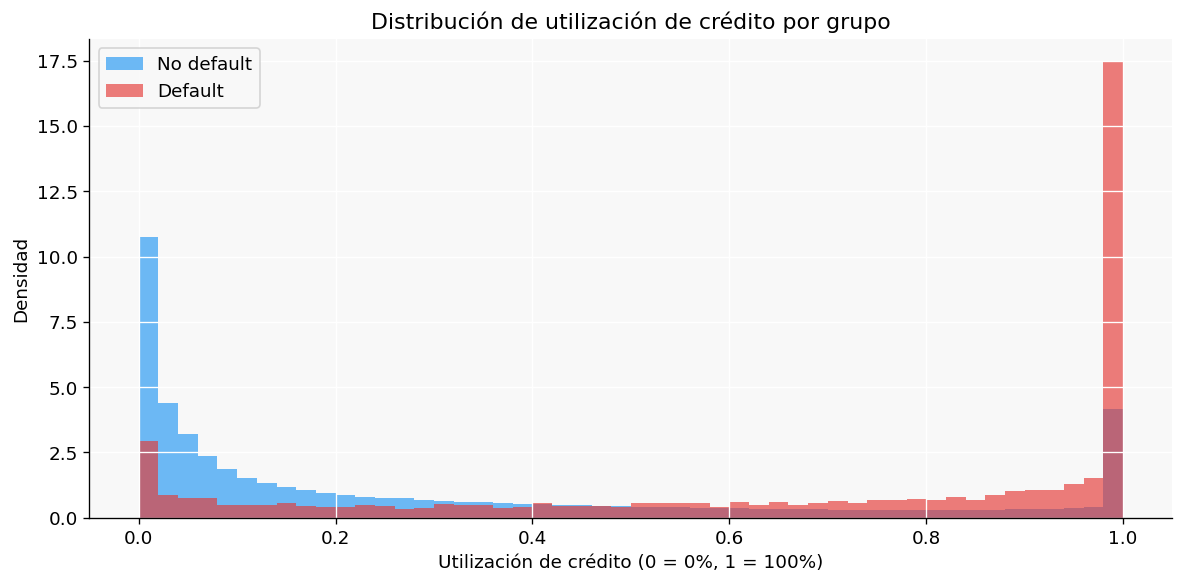

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df[df["SeriousDlqin2yrs"]==0]["RevolvingUtilizationOfUnsecuredLines"].clip(0, 1),
    bins=50, alpha=0.65, color="#2196F3",
    label="No default", density=True
)
ax.hist(
    df[df["SeriousDlqin2yrs"]==1]["RevolvingUtilizationOfUnsecuredLines"].clip(0, 1),
    bins=50, alpha=0.65, color="#E53935",
    label="Default", density=True
)

ax.set_xlabel("Utilización de crédito (0 = 0%, 1 = 100%)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de utilización de crédito por grupo")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "05_utilizacion_credito.png", bbox_inches="tight")
plt.show()

In [24]:
df["banda_util"] = pd.cut(
    df["RevolvingUtilizationOfUnsecuredLines"].clip(0, 1),
    bins=[0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.01],
    labels=["0-10%", "10-30%", "30-50%", "50-70%", "70-90%", "90-100%"],
    include_lowest=True
)

util_stats = df.groupby("banda_util", observed=True)["SeriousDlqin2yrs"].agg(
    total="count",
    defaults="sum"
).assign(tasa_default=lambda x: x["defaults"] / x["total"] * 100)

print(util_stats.round(2))

            total  defaults  tasa_default
banda_util                               
0-10%       64395      1165          1.81
10-30%      28475       895          3.14
30-50%      15830       926          5.85
50-70%      11340      1085          9.57
70-90%       9879      1468         14.86
90-100%     20067      4486         22.36


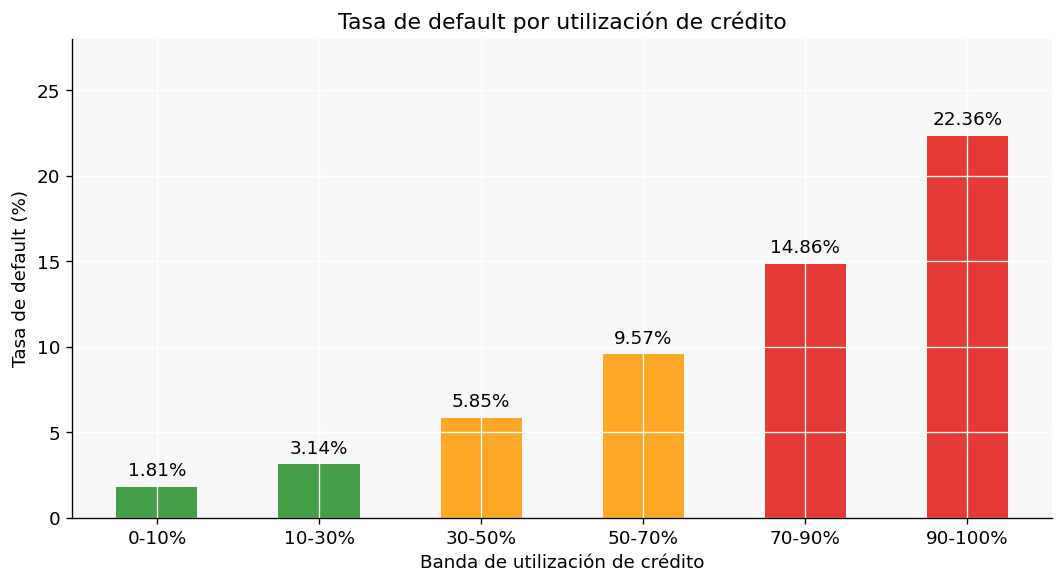

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    util_stats.index.astype(str),
    util_stats["tasa_default"],
    color=["#43A047", "#43A047", "#FFA726", "#FFA726", "#E53935", "#E53935"],
    width=0.5
)

ax.bar_label(bars, fmt="%.2f%%", padding=4)
ax.set_xlabel("Banda de utilización de crédito")
ax.set_ylabel("Tasa de default (%)")
ax.set_title("Tasa de default por utilización de crédito")
ax.set_ylim(0, 28)

plt.tight_layout()
plt.savefig(FIG_DIR / "06_default_por_utilizacion.png", bbox_inches="tight")
plt.show()

In [26]:
mora_stats = df[df["NumberOfTimes90DaysLate"] <= 10].groupby(
    "NumberOfTimes90DaysLate"
)["SeriousDlqin2yrs"].agg(
    total="count",
    defaults="sum"
).assign(tasa_default=lambda x: x["defaults"] / x["total"] * 100)

print(mora_stats.round(2))

                          total  defaults  tasa_default
NumberOfTimes90DaysLate                                
0.0                      141917      6700          4.72
1.0                        5243      1765         33.66
2.0                        1555       776         49.90
3.0                         667       385         57.72
4.0                         291       195         67.01
5.0                         131        83         63.36
6.0                          80        48         60.00
7.0                          38        31         81.58
8.0                          21        15         71.43
9.0                          19        14         73.68
10.0                          8         5         62.50


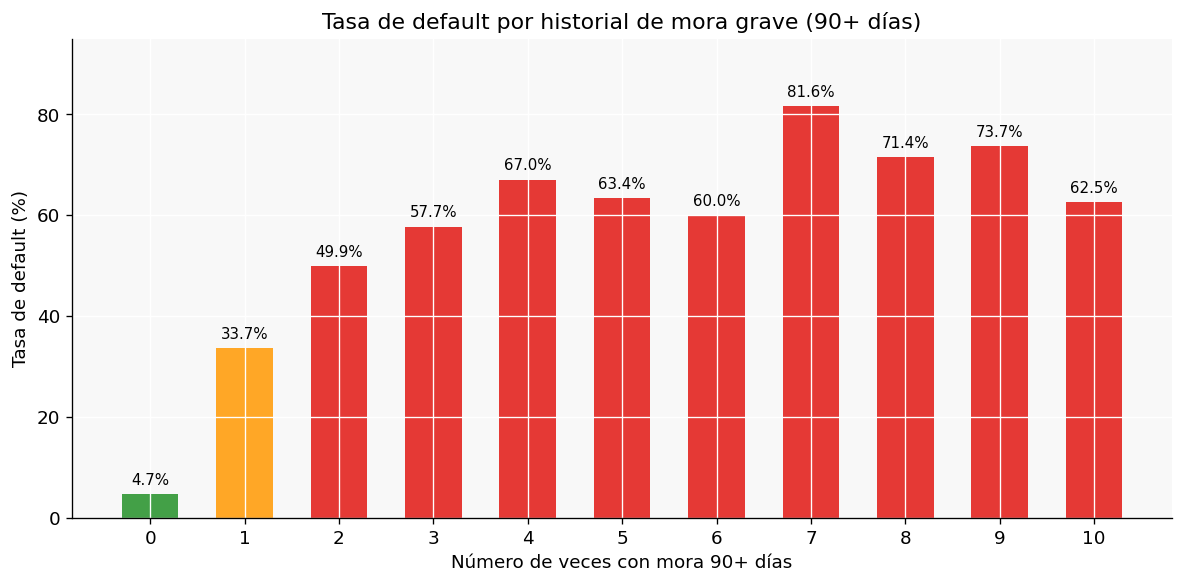

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    mora_stats.index.astype(int),
    mora_stats["tasa_default"],
    color=["#43A047" if t < 10 else "#FFA726" if t < 40 else "#E53935" 
           for t in mora_stats["tasa_default"]],
    width=0.6
)

ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set_xlabel("Número de veces con mora 90+ días")
ax.set_ylabel("Tasa de default (%)")
ax.set_title("Tasa de default por historial de mora grave (90+ días)")
ax.set_xticks(mora_stats.index.astype(int))
ax.set_ylim(0, 95)

plt.tight_layout()
plt.savefig(FIG_DIR / "07_default_por_mora90.png", bbox_inches="tight")
plt.show()

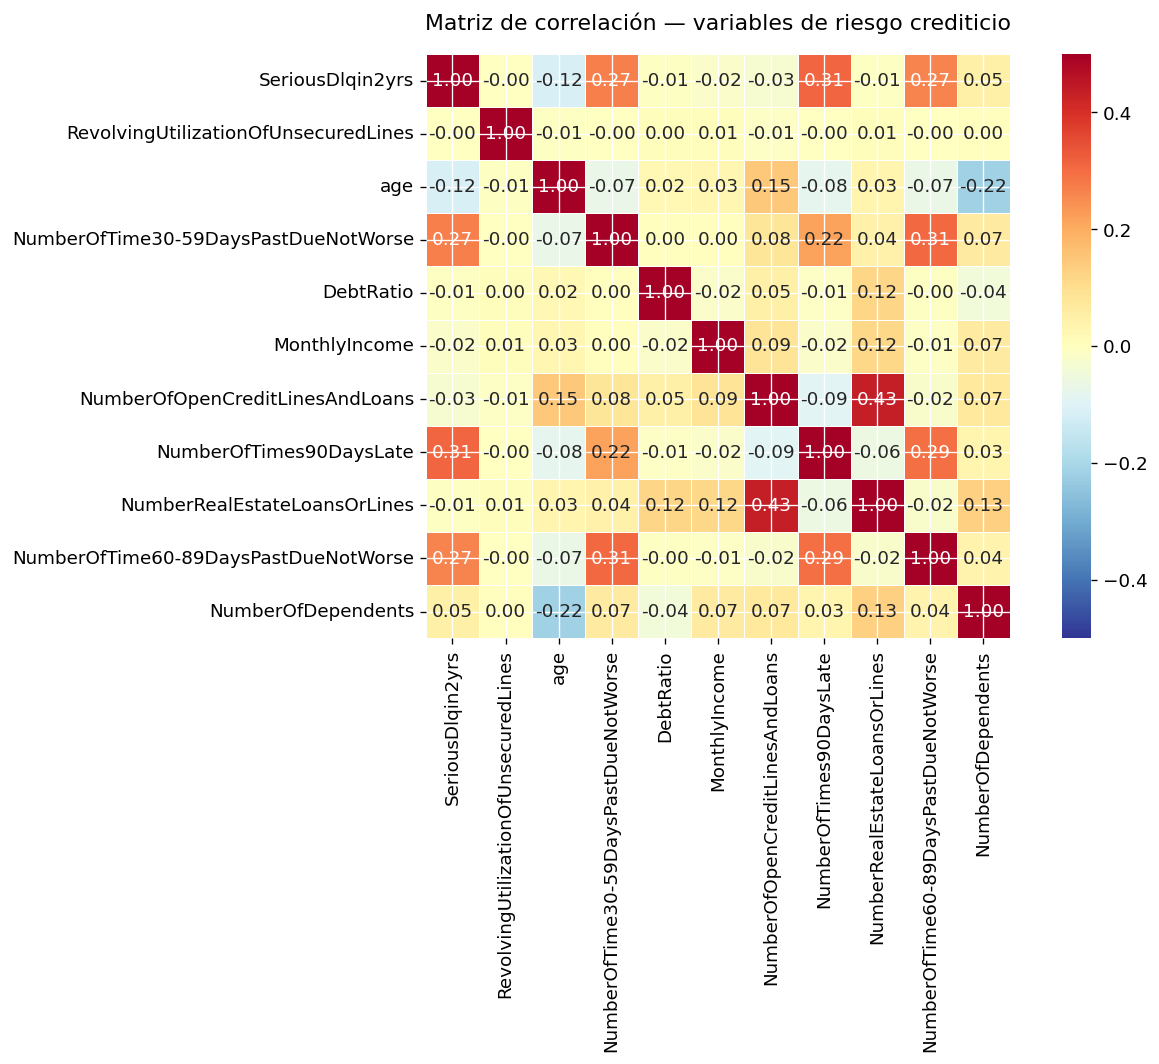

In [28]:
fig, ax = plt.subplots(figsize=(12, 9))

corr = df[[
    "SeriousDlqin2yrs",
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    vmin=-0.5,
    vmax=0.5,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Matriz de correlación — variables de riesgo crediticio", pad=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_correlacion.png", bbox_inches="tight")
plt.show()

In [29]:
tasa_global = df["SeriousDlqin2yrs"].mean() * 100
ingreso_default    = df[df["SeriousDlqin2yrs"]==1]["MonthlyIncome"].median()
ingreso_no_default = df[df["SeriousDlqin2yrs"]==0]["MonthlyIncome"].median()
util_default       = df[df["SeriousDlqin2yrs"]==1]["RevolvingUtilizationOfUnsecuredLines"].clip(0,1).median()
util_no_default    = df[df["SeriousDlqin2yrs"]==0]["RevolvingUtilizationOfUnsecuredLines"].clip(0,1).median()

print("=" * 55)
print("RESUMEN EJECUTIVO — Credit Risk EDA")
print("=" * 55)
print(f"\nTotal clientes analizados : {len(df):,}")
print(f"Tasa de default global    : {tasa_global:.2f}%")
print(f"\nIngreso mediano:")
print(f"  Default     : ${ingreso_default:,.0f}")
print(f"  No default  : ${ingreso_no_default:,.0f}")
print(f"\nUtilización mediana de crédito:")
print(f"  Default     : {util_default:.2%}")
print(f"  No default  : {util_no_default:.2%}")
print(f"\nHallazgos clave:")
print(f"  · Segmento más arriesgado : 18-35 años (>11% default)")
print(f"  · Segmento más seguro     : 65+ años (2.41% default)")
print(f"  · Clientes con uso >90%   : 22.36% de default")
print(f"  · Con 1 mora 90d previa   : 33.66% de default")
print(f"  · Con 2 moras 90d previas : 49.90% de default")
print("=" * 55)

RESUMEN EJECUTIVO — Credit Risk EDA

Total clientes analizados : 149,986
Tasa de default global    : 6.68%

Ingreso mediano:
  Default     : $5,240
  No default  : $5,400

Utilización mediana de crédito:
  Default     : 83.89%
  No default  : 13.33%

Hallazgos clave:
  · Segmento más arriesgado : 18-35 años (>11% default)
  · Segmento más seguro     : 65+ años (2.41% default)
  · Clientes con uso >90%   : 22.36% de default
  · Con 1 mora 90d previa   : 33.66% de default
  · Con 2 moras 90d previas : 49.90% de default


In [30]:
df.to_csv(
    DATA_PROCESSED / "credit_clean_es.csv",
    index=True,
    decimal=",",
    sep=";"
)
print("CSV exportado para Power BI ✓")

CSV exportado para Power BI ✓
